
DOWNLOAD NCBI
Proteínas encontradas: 9
Arquivo salvo: pipeline4/positive.fasta

DOWNLOAD NCBI
Proteínas encontradas: 3693
Arquivo salvo: pipeline4/negative.fasta

Arquivo: pipeline4/positive.fasta
Total: 9
Válidas: 9

Arquivo: pipeline4/negative.fasta
Total: 3693
Válidas: 2564

Dataset: (2573, 434)


Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       513
           1       1.00      1.00      1.00         2

    accuracy                           1.00       515
   macro avg       1.00      1.00      1.00       515
weighted avg       1.00      1.00      1.00       515

ROC-AUC          : 1.0
PR-AUC           : 1.0
MCC              : 1.0
F1               : 1.0
Precision        : 1.0
Recall           : 1.0
Balanced Accuracy: 1.0


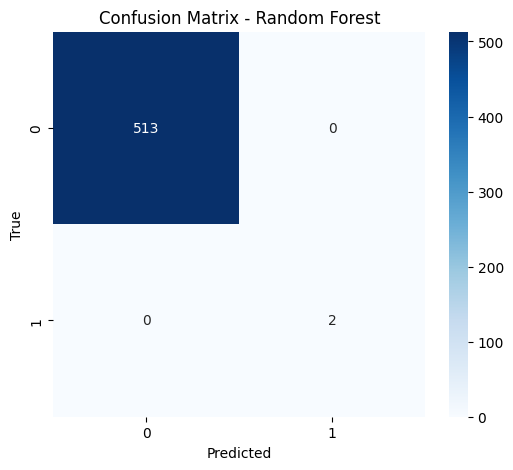

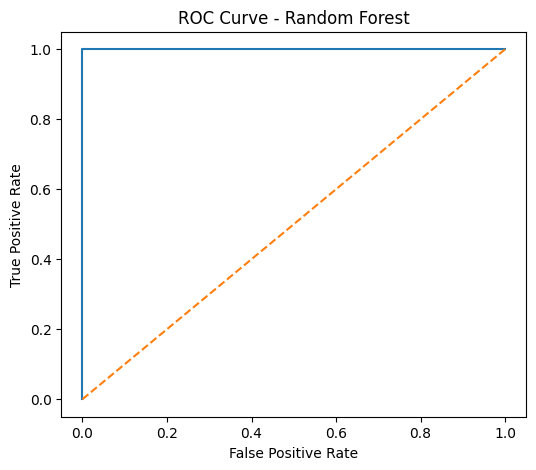



XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       513
           1       1.00      1.00      1.00         2

    accuracy                           1.00       515
   macro avg       1.00      1.00      1.00       515
weighted avg       1.00      1.00      1.00       515

ROC-AUC          : 1.0
PR-AUC           : 1.0
MCC              : 1.0
F1               : 1.0
Precision        : 1.0
Recall           : 1.0
Balanced Accuracy: 1.0


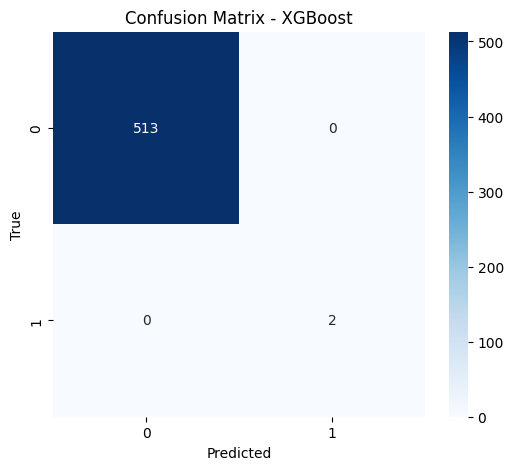

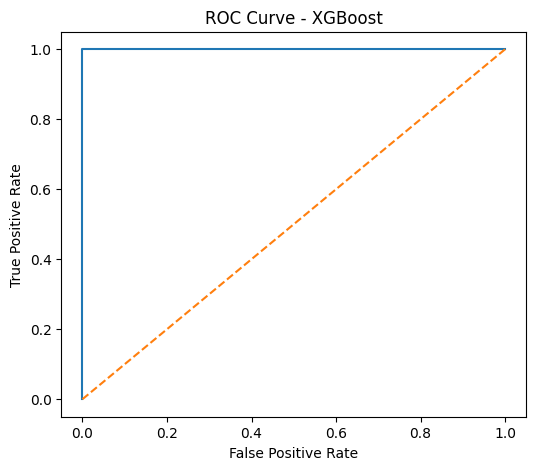



SVM
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       513
           1       1.00      1.00      1.00         2

    accuracy                           1.00       515
   macro avg       1.00      1.00      1.00       515
weighted avg       1.00      1.00      1.00       515

ROC-AUC          : 0.9999999999999999
PR-AUC           : 1.0
MCC              : 1.0
F1               : 1.0
Precision        : 1.0
Recall           : 1.0
Balanced Accuracy: 1.0


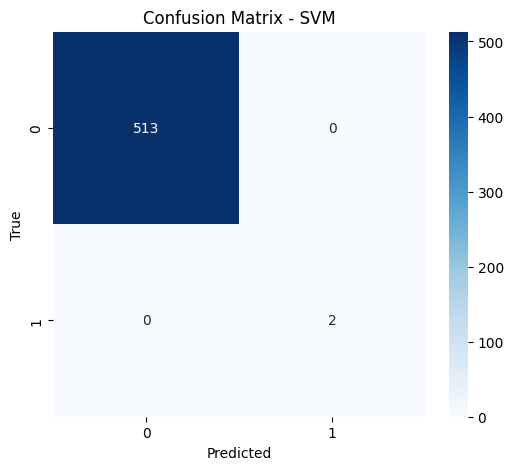

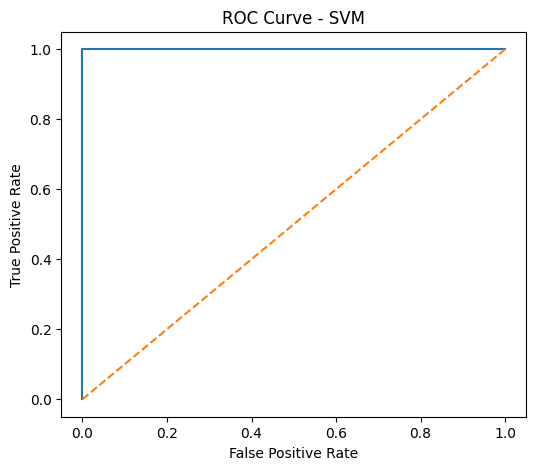


RF ROC-AUC: 0.9563352826510721
XGB ROC-AUC: 0.9666666666666666
SVM ROC-AUC: 0.8707602339181285


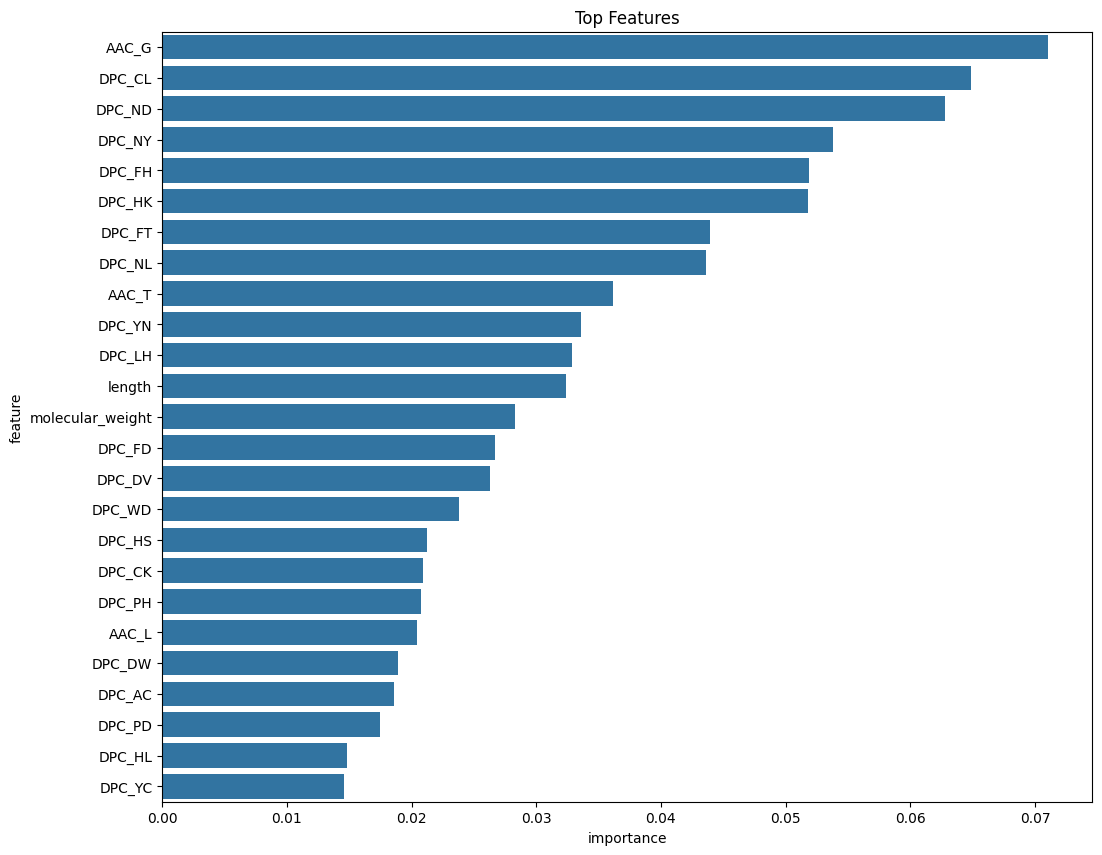


COMPARAÇÃO MODELOS
          Modelo  ROC_AUC   F1
0  Random Forest      1.0  1.0
1        XGBoost      1.0  1.0
2            SVM      1.0  1.0

DOWNLOAD TRANSCRIPTOMA
Transcritos encontrados: 1000
Arquivo salvo: pipeline4/arabidopsis_transcriptoma.fasta

TOP CANDIDATOS PHYSALIS
             id                                          descricao  \
156  OP991902.1  OP991902.1 Arabidopsis thaliana R-protein (RCY...   
266  MK776953.1  MK776953.1 Arabidopsis thaliana isolate Lerik1...   
14   PV383300.1  PV383300.1 Arabidopsis thaliana ecotype Pla-1 ...   
15   PV383299.1  PV383299.1 Arabidopsis thaliana ecotype Pla-1 ...   
150  OP036680.1  OP036680.1 Arabidopsis thaliana SIKIC2 gene, c...   
263  MK776956.1  MK776956.1 Arabidopsis thaliana isolate Mrk-0 ...   
119  OQ505038.1  OQ505038.1 Arabidopsis thaliana strain TueWal-...   
95   OQ505062.1  OQ505062.1 Arabidopsis thaliana strain IP-Pva-...   
105  OQ505052.1  OQ505052.1 Arabidopsis thaliana strain TRA-01 ...   
107  OQ505050.1  OQ5

In [17]:
# ==========================================================
# PIPELINE COMPLETO
# R-GENE PREDICTION EM PHYSALIS PERUVIANA
# BASEADO EM PROTEÍNAS + ORF PREDICTION
# ==========================================================
import os
import itertools
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from Bio import Entrez
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqUtils.ProtParam import ProteinAnalysis

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    matthews_corrcoef,
    f1_score,
    silhouette_score,
    davies_bouldin_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC 
from sklearn.preprocessing import StandardScaler 
from sklearn.pipeline import Pipeline 
from sklearn.metrics import ( precision_score, recall_score, balanced_accuracy_score )
import matplotlib.pyplot as plt
import seaborn as sns

Entrez.email = "marcela.leite@ifc.edu.br"
OUTPUT_DIR = "pipeline4"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================================
# DOWNLOAD PROTEÍNAS
# ==========================================================
def baixar_proteinas(query, arquivo_saida, max_records=10000):
    print("\n================================")
    print("DOWNLOAD NCBI")
    print("================================")
    handle = Entrez.esearch(
        db="protein",
        term=query,
        retmax=max_records
    )
    record = Entrez.read(handle)
    ids = record["IdList"]
    print("Proteínas encontradas:", len(ids))
    if len(ids) == 0:
        return

    handle = Entrez.efetch(
        db="protein",
        id=ids,
        rettype="fasta",
        retmode="text"
    )

    fasta = handle.read()
    with open(arquivo_saida, "w") as f:
        f.write(fasta)
    print("Arquivo salvo:", arquivo_saida)

# ==========================================================
# DOWNLOAD TRANSCRIPTOMA
# ==========================================================
def baixar_transcriptoma(query, arquivo_saida, max_records=10000):

    print("\n================================")
    print("DOWNLOAD TRANSCRIPTOMA")
    print("================================")

    handle = Entrez.esearch(
        db="nucleotide",
        term=query,
        retmax=max_records
    )
    record = Entrez.read(handle)
    ids = record["IdList"]
    print("Transcritos encontrados:", len(ids))
    if len(ids) == 0:
        return
    handle = Entrez.efetch(
        db="nucleotide",
        id=ids,
        rettype="fasta",
        retmode="text"
    )
    fasta = handle.read()
    with open(arquivo_saida, "w") as f:
        f.write(fasta)
    print("Arquivo salvo:", arquivo_saida)

# ==========================================================
# QUERY POSITIVA
# ==========================================================

positive_query = """
(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND ("Tobamovirus" OR "Potyvírus" OR "Tospovírus" OR "Crinivírus" OR "Cucumovírus" OR "Alfamovírus" OR "Sobemovírus" OR "ToBRFV" OR "TMV" OR "PVY" OR "PepYMV" OR "TSWV" OR "GRSV" OR "ToCV" OR "CMV" OR "TMV" OR "ToMV" )
AND
(
"NLR"
OR
"NBS-LRR"
OR
"NB-LRR"
OR
"TIR-NBS-LRR"
OR
"CC-NBS-LRR"
OR
"RLK"
OR
"RLP"
OR
"LRR receptor kinase" OR "leucine rich repeat receptor kinase"
OR
"plant disease resistance protein" OR "disease resistence protein"
OR
"RPM1"
OR
"RPS2"
OR
"RPS4"
OR
"RPS5"
OR
"RPP"
OR
"SNC1"
OR
"ADR1"
OR
"NDR1"
OR
"EDS1"
OR
"PAD4"
)
NOT
(
partial
OR
fragment
OR
hypothetical
OR
predicted
OR
DAP-seq
OR
"transcription factor"
OR
DNA-binding
OR
microtom
)
"""

# ==========================================================
# QUERY NEGATIVA
# ==========================================================

negative_query = """
(
"Solanum lycopersicum"[Organism]
OR
"Nicotiana benthamiana"[Organism]
)
AND
(
"actin"
OR
"tubulin"
OR
"ribosomal protein"
OR
"ATP synthase"
OR
"photosystem"
OR
"elongation factor"
OR
"glycolysis"
OR
"metabolic enzyme"
)
NOT
(
"resistance"
OR
"NLR"
OR
"LRR"
OR
"immune"
OR
"virus"
OR
microtom
OR
"NLR"
OR
"NBS-LRR"
OR
"NB-LRR"
OR
"TIR-NBS-LRR"
OR
"CC-NBS-LRR"
OR
"RLK"
OR
"RLP"
OR
"LRR receptor kinase" OR "leucine rich repeat receptor kinase"
OR
"plant disease resistance protein" OR "disease resistence protein"
OR
"RPM1"
OR
"RPS2"
OR
"RPS4"
OR
"RPS5"
OR
"RPP"
OR
"SNC1"
OR
"ADR1"
OR
"NDR1"
OR
"EDS1"
OR
"PAD4"
)
"""

# ==========================================================
# DOWNLOAD DATASETS
# ==========================================================

baixar_proteinas(
    positive_query,
    f"{OUTPUT_DIR}/positive.fasta"
)

baixar_proteinas(
    negative_query,
    f"{OUTPUT_DIR}/negative.fasta"
)

# ==========================================================
# AMINOÁCIDOS
# ==========================================================

AA = list("ACDEFGHIKLMNPQRSTVWY")

DIPEPTIDES = [
    a+b
    for a in AA
    for b in AA
]

# ==========================================================
# LIMPEZA
# ==========================================================

def limpar_proteina(seq):
    seq = seq.upper()
    valid = set(AA)
    seq = "".join([
        x for x in seq
        if x in valid
    ])
    return seq

# ==========================================================
# ORF PREDICTION
# ==========================================================

def encontrar_maior_orf(seq):
    seq = Seq(seq)
    longest = ""
    for strand, nuc in [
        (+1, seq),
        (-1, seq.reverse_complement())
    ]:
        for frame in range(3):
            translated = str(
                nuc[frame:].translate(to_stop=False)
            )
            proteins = translated.split("*")
            for protein in proteins:
                if len(protein) > len(longest):
                    longest = protein
    return longest

# ==========================================================
# AAC
# ==========================================================

def amino_acid_composition(seq):
    total = len(seq)
    if total == 0:
        return [0]*20
    return [
        seq.count(a)/total
        for a in AA
    ]

# ==========================================================
# DIPEPTIDES
# ==========================================================

def dipeptide_composition(seq):
    counts = dict.fromkeys(DIPEPTIDES, 0)
    total = len(seq)-1
    if total <= 0:
        return [0]*len(DIPEPTIDES)
    for i in range(total):
        dp = seq[i:i+2]
        if dp in counts:
            counts[dp] += 1
    return [
        counts[d]/total
        for d in DIPEPTIDES
    ]

# ==========================================================
# MOTIFS NB-LRR
# ==========================================================

def detectar_motifs(seq):
    motifs = {
        "P_LOOP_NTP": "GKTT",
        "KINASE_1": "VAIK",
        "GLPL": "GLPL",
        "MHD": "MHD",
        "LRR": "LxxLxLxx"
    }

    found = []
    for motif_name, motif in motifs.items():
        if motif.replace("x","") in seq:
            found.append(1)
        else:
            found.append(0)
    return found

# ==========================================================
# FEATURES BIOQUÍMICAS
# ==========================================================

def biochemical_features(seq):

    try:
        analysis = ProteinAnalysis(seq)
        mw = analysis.molecular_weight()
        aromaticity = analysis.aromaticity()
        instability = analysis.instability_index()
        gravy = analysis.gravy()
        iso = analysis.isoelectric_point()
        helix, turn, sheet = analysis.secondary_structure_fraction()
        return [
            mw,
            aromaticity,
            instability,
            gravy,
            iso,
            helix,
            turn,
            sheet
        ]
    except:
        return [0]*8

# ==========================================================
# EXTRAÇÃO FEATURES
# ==========================================================

def extract_features(seq):
    seq = limpar_proteina(seq)
    if len(seq) < 100:
        return None
    try:
        aac = amino_acid_composition(seq)
        dpc = dipeptide_composition(seq)
        bio = biochemical_features(seq)
        motifs = detectar_motifs(seq)
        length = [len(seq)]
        return (
            aac +
            dpc +
            bio +
            motifs +
            length
        )
    except:
        return None

# ==========================================================
# DATASET
# ==========================================================

X = []
y = []
ids = []

def processar_proteinas(fasta, label):
    total = 0
    validas = 0

    for record in SeqIO.parse(fasta, "fasta"):
        total += 1
        desc = record.description.lower()
        bad_terms = [
            "partial",
            "fragment",
            "hypothetical",
            "predicted"
        ]
        if any(t in desc for t in bad_terms):
            continue

        seq = str(record.seq)
        feats = extract_features(seq)
        if feats is not None:
            X.append(feats)
            y.append(label)
            ids.append(record.id)
            validas += 1

    print("\nArquivo:", fasta)
    print("Total:", total)
    print("Válidas:", validas)

# ==========================================================
# PROCESSAMENTO
# ==========================================================

processar_proteinas(
    f"{OUTPUT_DIR}/positive.fasta",
    1
)

processar_proteinas(
    f"{OUTPUT_DIR}/negative.fasta",
    0
)

# ==========================================================
# ARRAYS
# ==========================================================
X = np.array(X)
y = np.array(y)
print("\nDataset:", X.shape)

# ==========================================================
# COLUNAS
# ==========================================================

aac_cols = [f"AAC_{a}" for a in AA]
dpc_cols = [f"DPC_{d}" for d in DIPEPTIDES]
bio_cols = [
    "molecular_weight",
    "aromaticity",
    "instability",
    "gravy",
    "isoelectric_point",
    "helix",
    "turn",
    "sheet"
]

motif_cols = [
    "motif_p_loop",
    "motif_kinase",
    "motif_glpl",
    "motif_mhd",
    "motif_lrr"
]

columns = (
    aac_cols +
    dpc_cols +
    bio_cols +
    motif_cols +
    ["length"]

)

# ==========================================================
# DATAFRAME
# ==========================================================

df = pd.DataFrame(
    X,
    columns=columns
)

df["label"] = y
df["id"] = ids
df.to_csv(
    f"{OUTPUT_DIR}/dataset_proteico.csv",
    index=False
)

# ==========================================================
# TRAIN TEST
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

# ==========================================================
# RANDOM FOREST
# ==========================================================

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=30,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

# ==========================================================
# XGBOOST
# ==========================================================

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

# ========================================================== 
# SUPPORT VECTOR MACHINE 
# ========================================================== 

svm_model = Pipeline([ ("scaler", StandardScaler()),
                    ("svm", SVC( kernel="rbf", 
                                probability=True, 
                                class_weight="balanced", 
                                C=2, gamma="scale", 
                                random_state=42 )) ]) 
svm_model.fit(X_train, y_train) 
svm_pred = svm_model.predict(X_test) 
svm_prob = svm_model.predict_proba(X_test)[:,1]

# ==========================================================
# AVALIAÇÃO
# ==========================================================

def avaliar_modelo(nome, y_true, pred, prob):
    print("\n")
    print("="*60)
    print(nome)
    print("="*60)
    print(classification_report(y_true, pred))
    auc = roc_auc_score(y_true, prob)
    pr_auc = average_precision_score(y_true, prob)
    mcc = matthews_corrcoef(y_true, pred)
    f1 = f1_score(y_true, pred)
    precision = precision_score(y_true, pred)
    recall = recall_score(y_true, pred)
    balanced_acc = balanced_accuracy_score(
        y_true,
        pred
    )
    print("ROC-AUC          :", auc)
    print("PR-AUC           :", pr_auc)
    print("MCC              :", mcc)
    print("F1               :", f1)
    print("Precision        :", precision)
    print("Recall           :", recall)
    print("Balanced Accuracy:", balanced_acc)

    # ======================================================
    # MATRIZ CONFUSÃO
    # ======================================================

    cm = confusion_matrix(y_true, pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {nome}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ======================================================
    # ROC
    # ======================================================
    fpr, tpr, _ = roc_curve(y_true, prob)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {nome}")
    plt.show()

avaliar_modelo(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

avaliar_modelo(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

avaliar_modelo(
    "SVM",
    y_test,
    svm_pred,
    svm_prob
)

# ==========================================================
# CROSS VALIDATION
# ==========================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42
)

scores_rf = cross_val_score(

    rf,
    X,
    y,

    cv=cv,

    scoring="roc_auc"
)

scores_xgb = cross_val_score(

    xgb,
    X,
    y,

    cv=cv,

    scoring="roc_auc"
)

scores_svm = cross_val_score(

    svm_model,

    X,

    y,

    cv=cv,

    scoring="roc_auc"
)

print("\nRF ROC-AUC:", scores_rf.mean())
print("XGB ROC-AUC:", scores_xgb.mean())
print("SVM ROC-AUC:", scores_svm.mean())
# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================
importance = pd.DataFrame({
    "feature": columns,
    "importance": xgb.feature_importances_
})
importance = importance.sort_values(
    by="importance",
    ascending=False
)
importance.to_csv(
    f"{OUTPUT_DIR}/feature_importance.csv",
    index=False
)
plt.figure(figsize=(12,10))
sns.barplot(
    data=importance.head(25),
    x="importance",
    y="feature"
)
plt.title("Top Features")
plt.show()


# ==========================================================
# COMPARAÇÃO MODELOS
# ==========================================================

comparacao = pd.DataFrame({

    "Modelo": [

        "Random Forest",
        "XGBoost",
        "SVM"

    ],

    "ROC_AUC": [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, svm_prob)
    ],
    "F1": [
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, svm_pred)
    ]
})

print("\nCOMPARAÇÃO MODELOS")
print(comparacao)
comparacao.to_csv(
    f"{OUTPUT_DIR}/comparacao_modelos.csv",
    index=False
)

# ==========================================================
# BAIXAR TRANSCRIPTOMA PHYSALIS
# ==========================================================

# physalis_query = """
# "Physalis peruviana"[Organism]
# AND
# (
# transcriptome
# OR
# mRNA
# OR
# RNA-Seq
# OR
# TSA
# )
# NOT
# (
# genome
# OR
# chromosome
# OR
# scaffold
# OR
# contig
# )
# """

# baixar_transcriptoma(
#     physalis_query,
#     f"{OUTPUT_DIR}/physalis_transcriptoma.fasta",
#     3000
# )

arabidopsis_query = """
"Arabidopsis thaliana"[Organism]
AND
(
transcriptome
OR
mRNA
OR
RNA-Seq
OR
TSA
)
NOT
(
genome
OR
chromosome
OR
scaffold
OR
contig
)
"""
baixar_transcriptoma(
    arabidopsis_query,
    f"{OUTPUT_DIR}/arabidopsis_transcriptoma.fasta",
    1000
)


# ==========================================================
# PREDIÇÃO EM PHYSALIS
# ==========================================================

resultados = []

# for record in SeqIO.parse(
#     f"{OUTPUT_DIR}/physalis_transcriptoma.fasta",
#     "fasta"
# ):
for record in SeqIO.parse(
    f"{OUTPUT_DIR}/arabidopsis_transcriptoma.fasta",
    "fasta"
):
    desc = record.description.lower()

    bad_terms = [

        "partial",
        "non-coding",
        "ncrna",
        "lncrna",
        "mirna",
        "sirna"

    ]

    if any(t in desc for t in bad_terms):
        continue

    rna_seq = str(record.seq)

    # ==========================================
    # ENCONTRAR MAIOR ORF
    # ==========================================

    protein_seq = encontrar_maior_orf(rna_seq)

    if len(protein_seq) < 100:
        continue

    # ==========================================
    # FEATURES
    # ==========================================

    feats = extract_features(protein_seq)

    if feats is None:
        continue

    feats = np.array(feats).reshape(1,-1)
    prob = xgb.predict_proba(feats)[0][1]
    resultados.append({
        "id": record.id,
        "descricao": record.description,
        "protein_length": len(protein_seq),
        "probabilidade_resistencia": prob

    })

# ==========================================================
# RESULTADOS
# ==========================================================

df_res = pd.DataFrame(resultados)

df_res = df_res.sort_values(
    by="probabilidade_resistencia",
    ascending=False
)

df_res.to_csv(
    # f"{OUTPUT_DIR}/predicoes_physalis.csv",
    f"{OUTPUT_DIR}/predicoes_arabidopsis.csv",
    index=False
)

print("\nTOP CANDIDATOS PHYSALIS")

print(df_res.head(20))


# ==========================================================
# VALIDAÇÃO BIOLÓGICA DOS CANDIDATOS
# ==========================================================

print("\nVALIDAÇÃO BIOLÓGICA")

top = df_res.head(50)

motif_stats = {

    "P_LOOP": 0,
    "GLPL": 0,
    "MHD": 0

}

for idx, row in top.iterrows():

    transcript_id = row["id"]

    for record in SeqIO.parse(
        # f"{OUTPUT_DIR}/physalis_transcriptoma.fasta",
        f"{OUTPUT_DIR}/arabidopsis_transcriptoma.fasta",
        "fasta"
    ):

        if record.id == transcript_id:

            protein_seq = encontrar_maior_orf(
                str(record.seq)
            )

            if "GKTT" in protein_seq:
                motif_stats["P_LOOP"] += 1

            if "GLPL" in protein_seq:
                motif_stats["GLPL"] += 1

            if "MHD" in protein_seq:
                motif_stats["MHD"] += 1

            break

print("\nMotifs encontrados nos TOP candidatos:")

for k,v in motif_stats.items():

    print(k, ":", v)

print("\nPIPELINE FINALIZADO")